In [27]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
from notebooks.imports import *
import re

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load Config

In [28]:
from config import dir_config, main_config

raw_dir = Path(dir_config.data.raw)
processed_dir = Path(dir_config.data.processed)

mds_updrs_conf = main_config.MDS_UPDRS

### Import Data

In [29]:
session_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)

# replace categorical values with integers
session_metadata['Were_Diskinesias_Present'] = session_metadata['Were_Diskinesias_Present'].map({'yes': 1, 'no': 0})
session_metadata['Did_these_Movements_Interfere_with_Ratings'] = session_metadata['Did_these_Movements_Interfere_with_Ratings'].map({'yes': 1, 'no': 0})

In [30]:
all_subjects = session_metadata['subject_id'].unique()
stanford_subjects = session_metadata[session_metadata['experiment_site'] == 'Stanford']['subject_id'].unique()
ucla_subjects = session_metadata[session_metadata['experiment_site'] == 'UCLA']['subject_id'].unique()
case_western_subjects = session_metadata[session_metadata['experiment_site'] == 'Case_Western']['subject_id'].unique()
harvard_subjects = session_metadata[session_metadata['experiment_site'] == 'Harvard']['subject_id'].unique()

# Subjects that have at least one treatment session are PD; the rest are HC
pd_subjects = session_metadata[session_metadata['treatment'].notna()]['subject_id'].unique()
hc_subjects = [s for s in all_subjects if s not in pd_subjects]

new_subjects = list(set(stanford_subjects) | (set(harvard_subjects) & set(pd_subjects)))

print(f"Total subjects: {len(all_subjects)} (PD: {len(pd_subjects)}, HC: {len(hc_subjects)})")
print(f"  Stanford: {len(stanford_subjects)}, UCLA: {len(ucla_subjects)}, Case Western: {len(case_western_subjects)}, Harvard: {len(harvard_subjects)}")
print(f"New-cohort PD subjects: {len(new_subjects)}")


Total subjects: 48 (PD: 40, HC: 8)
  Stanford: 16, UCLA: 15, Case Western: 4, Harvard: 13
New-cohort PD subjects: 21


### Score Calculation

Calculate UPDRS, Tremor and Bradykinesia Scores

In [31]:
# Identify and validate variables
def get_valid_vars(item_list, df_columns, label):
    valid_vars = []
    for var in item_list:
        assert var in df_columns, (
            f"Variable {var} not found in DataFrame columns for {label}"
        )
        valid_vars.append(var)
    return valid_vars


relevant_UPDRS_vars = get_valid_vars(mds_updrs_conf.UPDRS_ITEMS, session_metadata.columns, "UPDRS")
relevant_tremor_vars = get_valid_vars(mds_updrs_conf.TREMOR_ITEMS, session_metadata.columns, "TREMOR")
relevant_bradykinesia_vars = get_valid_vars(mds_updrs_conf.BRADYKINESIA_ITEMS, session_metadata.columns, "BRADYKINESIA")
relevant_pigd_vars = get_valid_vars(mds_updrs_conf.PIGD_ITEMS, session_metadata.columns, "PIGD")

# Filter new_subjects index
new_subjects_idx = session_metadata.index[session_metadata["subject_id"].isin(new_subjects)]


# Helper to safely convert to numeric
def to_numeric_df(df):
    return df.apply(pd.to_numeric, errors="coerce")


# Compute scores
updrs_numeric = to_numeric_df(session_metadata.loc[new_subjects_idx, relevant_UPDRS_vars])
tremor_numeric = to_numeric_df(session_metadata.loc[new_subjects_idx, relevant_tremor_vars])
brady_numeric = to_numeric_df(session_metadata.loc[new_subjects_idx, relevant_bradykinesia_vars])
pigd_numeric = to_numeric_df(session_metadata.loc[new_subjects_idx, relevant_pigd_vars])

session_metadata.loc[new_subjects_idx, "UPDRS"] = np.nansum(updrs_numeric, axis=1)
session_metadata.loc[new_subjects_idx, "tremor_score"] = np.nanmean(tremor_numeric, axis=1)
session_metadata.loc[new_subjects_idx, "bradykinesia_score"] = np.nanmean(brady_numeric, axis=1)
session_metadata.loc[new_subjects_idx, "pigd_score"] = np.nanmean(pigd_numeric, axis=1)

# Compute ratios with division safety
with np.errstate(divide="ignore", invalid="ignore"):
    trem_by_brady = session_metadata.loc[new_subjects_idx, "tremor_score"] / session_metadata.loc[new_subjects_idx, "bradykinesia_score"]
    trem_by_pigd = session_metadata.loc[new_subjects_idx, "tremor_score"] / session_metadata.loc[new_subjects_idx, "pigd_score"]

# Assign results
session_metadata.loc[new_subjects_idx, "trem_by_brady"] = trem_by_brady.replace([np.inf, -np.inf], np.nan)
session_metadata.loc[new_subjects_idx, "trem_by_pigd"] = trem_by_pigd.replace([np.inf, -np.inf], np.nan)


In [32]:
def get_label(value, thresholds):
    for label, (low, high) in thresholds.items():
        if low <= value <= high:
            return label
    print(f"Warning: value {value} did not match any threshold.")
    return "unknown"


for subject in new_subjects:
    subject_indices = session_metadata.index[session_metadata["subject_id"] == subject]
    subject_data = session_metadata.loc[subject_indices]

    off_rows = subject_data[subject_data["treatment"] == "OFF"]

    if off_rows.empty:
        print(f"No OFF-treatment data for subject {subject}. Skipping...")
        continue

    # Use first OFF row
    off_row = off_rows.iloc[0]

    trem_vs_brady_type = get_label(
        off_row["trem_by_brady"], mds_updrs_conf.TREM_VS_BRADY
    )
    pigd_vs_tremor_type = get_label(
        off_row["trem_by_pigd"], mds_updrs_conf.TREM_VS_PIDG
    )

    session_metadata.loc[subject_indices, "trem_vs_brady_type"] = trem_vs_brady_type
    session_metadata.loc[subject_indices, "pigd_vs_tremor_type"] = pigd_vs_tremor_type

# Now create composite columns
session_metadata["trem_vs_non-trem"] = np.where(
    (session_metadata["trem_vs_brady_type"] == "tremor")
    | (session_metadata["pigd_vs_tremor_type"] == "tremor"),
    "tremor",
    "non-tremor",
)

session_metadata["pigd_vs_non-pigd"] = np.where(
    session_metadata["pigd_vs_tremor_type"] == "pigd", "pigd", "non-pigd"
)


In [33]:
session_metadata

,subject_id,gender,age,years_since_diagnosis,pd_meds,is_pd,treatment,off_med_first,is_tremor_dominant,MoCA,sMMSE,BDI,BAI,UPDRS,off_meds_hrs,210_Tremor,212_Balance,213_Freezing,301_Speech,302_Facial_Expression,303a_Rigidity_Neck,303b_Rigidity_RUE,303c_Rigidity_LUE,303d_Rigidity_RLE,303e_Rigidity_LLE,304a_Finger_Tapping_RUE,304b_Finger_Tapping_LUE,305a_Hand_Movements_RUE,305b_Hand_Movements_LUE,306a_Pronation_Supination_Movements_RUE,306b_Pronation_Supination_Movements_LUE,307a_Toe_Tapping_RLE,307b_Toe_Tapping_LLE,308a_Leg_Agility_RLE,308b_Leg_Agility_LLE,309_Arising_from_Chair,310_Gait,311_Freezing_of_Gait,312_Postural_Stability,313_Posture,314_Global_Spontaneity_of_Movement,315a_Postural_Tremor_RUE,315b_Postural_Tremor_LUE,316a_Kinetic_Tremor_RUE,316b_Kinetic_Tremor_LUE,317a_Rest_Tremor_Amplitude_RUE,317b_Rest_Tremor_Amplitude_LUE,317c_Rest_Tremor_Amplitude_RLE,317d_Rest_Tremor_Amplitude_LLE,317e_Rest_Tremor_Amplitude_Lip_Jaw,318_Constancy_of_Rest_Tremor,Were_Diskinesias_Present,Did_these_Movements_Interfere_with_Ratings,Hoehn_and_Yahr_Stage,notes,Unnamed: 55,experiment_site,prior_condition,file_name,positive_bias,positive_psych_alpha,positive_psych_beta,positive_psych_lapse,positive_psych_guess,equal_psych_bias,equal_psych_alpha,equal_psych_beta,equal_psych_lapse,equal_psych_guess,positive_psych_bias,equal_bias,session_id,tremor_score,bradykinesia_score,pigd_score,trem_by_brady,trem_by_pigd,trem_vs_brady_type,pigd_vs_tremor_type,trem_vs_non-trem,pigd_vs_non-pigd
0,P1,M,64.0,7.0,carbidopa-levodopa (Sinemet) 25-100 mg tablet;...,1,OFF,1.0,NaN,NaN,NaN,NaN,NaN,18.0,24,1.0,1.0,2.0,0.0,1.0,1.0,0.0,2.0,NaN,NaN,1.0,2.0,1.0,2.0,1.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,NaN,Stanford,rr,P1_OFFmeds_rr.mat,0.394737,9.548708,0.052991,0.006751,0.011776,0.429653,7.795582,0.063467,0.021178,0.094816,0.380941,0.414286,P1_OFF,0.181818,0.928571,1.000000,0.195804,0.181818,bradykinetic,pigd,non-tremor,pigd
1,P1,M,64.0,7.0,carbidopa-levodopa (Sinemet) 25-100 mg tablet;...,1,ON,1.0,NaN,26.0,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,0.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,NaN,Stanford,gr,P1_ONmeds_gr.mat,0.723684,-11.994054,0.067302,0.023186,0.100474,0.451841,5.865186,0.045781,0.000010,0.032772,0.706478,0.400000,P1_ON,0.300000,0.687500,0.666667,0.436364,0.450000,bradykinetic,pigd,non-tremor,pigd
2,P3,F,59.0,6.0,carbidopa-levodopa (Sinemet) 25-100 mg tablet,1,OFF,1.0,NaN,27.0,NaN,NaN,NaN,10.0,12.5,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,Stanford,rr,P3_OFFmeds_rr.mat,0.388889,6.631412,0.013245,0.200000,0.000010,0.406585,54.057324,0.019519,0.000010,0.200000,0.382450,0.482759,P3_OFF,0.454545,0.250000,0.200000,1.818182,2.272727,tremor,tremor,tremor,non-pigd
3,P3,F,59.0,6.0,carbidopa-levodopa (Sinemet) 25-100 mg tablet,1,ON,1.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,NaN,Stanford,gr,P3_ONmeds_gr.mat,0.434211,55.269669,0.006553,0.200000,0.200000,0.379991,24.197426,0.012323,0.108020,0.000010,0.446258,0.379747,P3_ON,0.100000,0.187500,0.000000,0.533333,NaN,tremor,tremor,tremor,non-pigd
4,P4,M,79.0,3.0,carbidopa-levodopa (Sinemet CR) 25-100 mg tablet,1,OFF,1.0,NaN,29.0,NaN,NaN,NaN,18.0,25,1.0,0.0,0.0,1.0,3.0,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,2.0,NaN,NaN,2.0,NaN,NaN,Stanford,rl,P4_OFFmeds_rl.mat,0.571429,-8.139609,0.027590,0.004454,0.000010,0.471327,5.011135,0.050707,0.017031,0.074489,0.553437,0.512821,P4_OFF,0.400000,0.500000,0.200000,0.800000,2.000000,bradykinetic,tremor,tremor,non-pigd
5,P4,M,79.0,3.0,carbidopa-levodopa (Sinemet CR) 25-100 mg tablet,1

In [34]:
# session_metadata['categorization'] = np.nan
# session_metadata['trem_vs_brady'] = np.nan
# session_metadata['trem_vs_pigd'] = np.nan

# for sub in session_metadata['subject_id'].unique():
#     # get indices of the subject
#     idx = session_metadata[session_metadata['subject_id'] == sub].index
#     off_idx = session_metadata[(session_metadata['subject_id'] == sub) & (session_metadata['treatment'] == 'OFF')].index

#     if session_metadata.loc[off_idx, 'categorization_score'].values[0] <= 0.8:
#         session_metadata.loc[idx, 'categorization'] = 'bradykinesia_dominant'
#     elif session_metadata.loc[off_idx, 'categorization_score'].values[0] >= 1:
#         session_metadata.loc[idx, 'categorization'] = 'tremor_dominant'
#     elif 0.8 < session_metadata.loc[off_idx, 'categorization_score'].values[0] < 1:
#         session_metadata.loc[idx, 'categorization'] = 'intermediate'


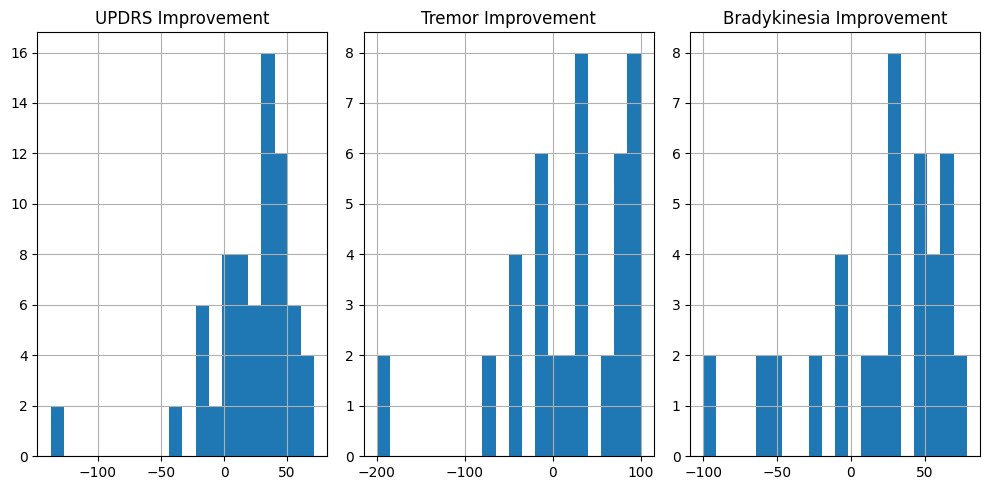

In [35]:
# Ensure improvement columns exist
session_metadata["UPDRS_improvement"] = np.nan
session_metadata["tremor_improvement"] = np.nan
session_metadata["bradykinesia_improvement"] = np.nan

for sub in session_metadata['subject_id'].unique():
    sub_data = session_metadata[session_metadata['subject_id'] == sub]
    if sub_data['treatment'].nunique() < 2:
        continue  # skip if both OFF and ON not present

    try:
        off_row = sub_data[sub_data['treatment'] == 'OFF'].iloc[0]
        on_row = sub_data[sub_data['treatment'] == 'ON'].iloc[0]

        def percent_improvement(off, on):
            return np.nan if off == 0 else (off - on) * 100 / off

        ui = percent_improvement(off_row['UPDRS'], on_row['UPDRS'])
        ti = percent_improvement(off_row['tremor_score'], on_row['tremor_score'])
        bi = percent_improvement(off_row['bradykinesia_score'], on_row['bradykinesia_score'])

        session_metadata.loc[sub_data.index, 'UPDRS_improvement'] = ui
        session_metadata.loc[sub_data.index, 'tremor_improvement'] = ti
        session_metadata.loc[sub_data.index, 'bradykinesia_improvement'] = bi

    except (IndexError, KeyError, TypeError):
        continue  # skip subjects with missing or malformed data

# Plot histogram
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
session_metadata['UPDRS_improvement'].hist(bins=20, ax=ax[0])
ax[0].set_title('UPDRS Improvement')
session_metadata['tremor_improvement'].hist(bins=20, ax=ax[1])
ax[1].set_title('Tremor Improvement')
session_metadata['bradykinesia_improvement'].hist(bins=20, ax=ax[2])
ax[2].set_title('Bradykinesia Improvement')
plt.tight_layout()
plt.show()

In [36]:
# Build ON/OFF index pairs — PD subjects only
treatment_idx_all = pd.DataFrame(columns=['subject', 'off', 'on'])

for idx, sub in enumerate(pd_subjects):
    sub_df = session_metadata.loc[session_metadata['subject_id'] == sub]
    off_idx = sub_df.loc[sub_df['treatment'] == 'OFF'].index
    on_idx  = sub_df.loc[sub_df['treatment'] == 'ON'].index
    if off_idx.empty or on_idx.empty:
        print(f"Subject {sub} missing ON or OFF session — skipping.")
        continue
    treatment_idx_all.loc[len(treatment_idx_all)] = [sub, off_idx[0], on_idx[0]]

print(f"PD subjects with both ON and OFF sessions: {len(treatment_idx_all)}")


PD subjects with both ON and OFF sessions: 40


### Assess scores

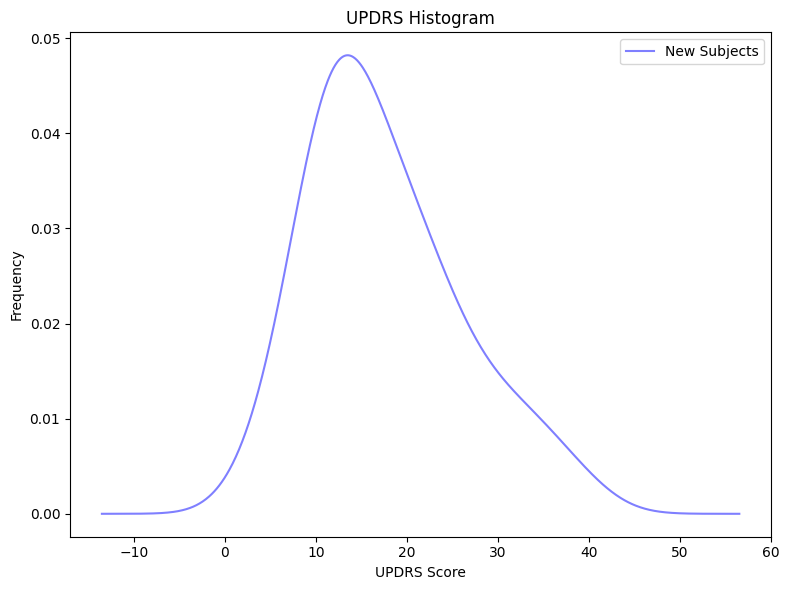

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

session_metadata.loc[session_metadata["subject_id"].isin(new_subjects), 'UPDRS'].plot(kind='kde', alpha=0.5, color='blue', ax=ax, label="New Subjects")
# session_metadata.loc[session_metadata["subject_id"].isin(ucla_subjects), 'UPDRS'].plot(kind='kde', alpha=0.5, color='red', ax=ax, label="UCLA Subjects")

ax.set_title('UPDRS Histogram')
ax.set_xlabel('UPDRS Score')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()


Subjects with higher UPDRS with medication: ['P4' 'P9' 'P12' 'P29' 'P33' 'ALE']


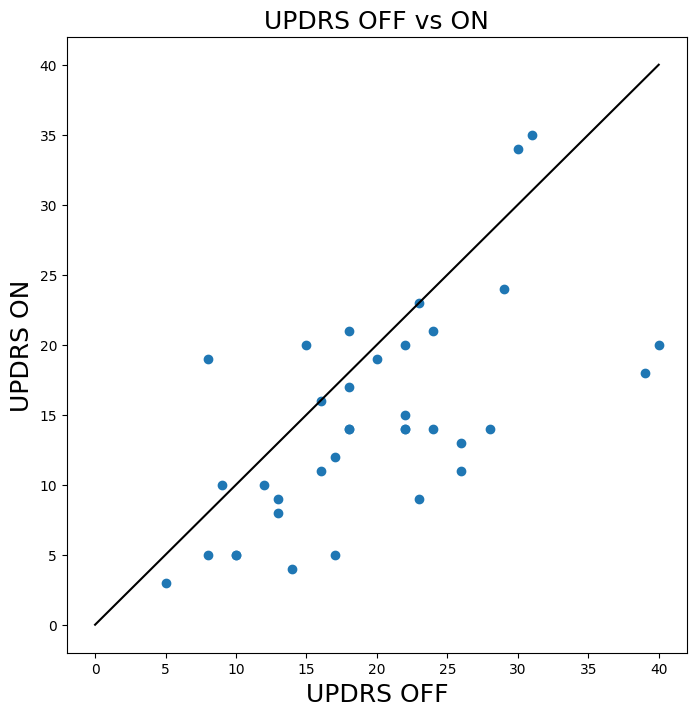

In [38]:

# get name of subjects where off UPDRS is greater than on UPDRS
print(f"Subjects with higher UPDRS with medication: {session_metadata.loc[treatment_idx_all['off'], 'subject_id'][(session_metadata.loc[treatment_idx_all['off'], 'UPDRS'].values < session_metadata.loc[treatment_idx_all['on'], 'UPDRS'].values)].values}")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plt.plot(session_metadata.loc[treatment_idx_all["off"], 'UPDRS'], session_metadata.loc[treatment_idx_all["on"], 'UPDRS'], 'o')
plt.plot([0, 40], [0, 40], 'k-')
plt.xlabel('UPDRS OFF', fontsize=18)
plt.ylabel('UPDRS ON', fontsize=18)
plt.title('UPDRS OFF vs ON', fontsize=18)
plt.show()


(-0.1, 2.0)

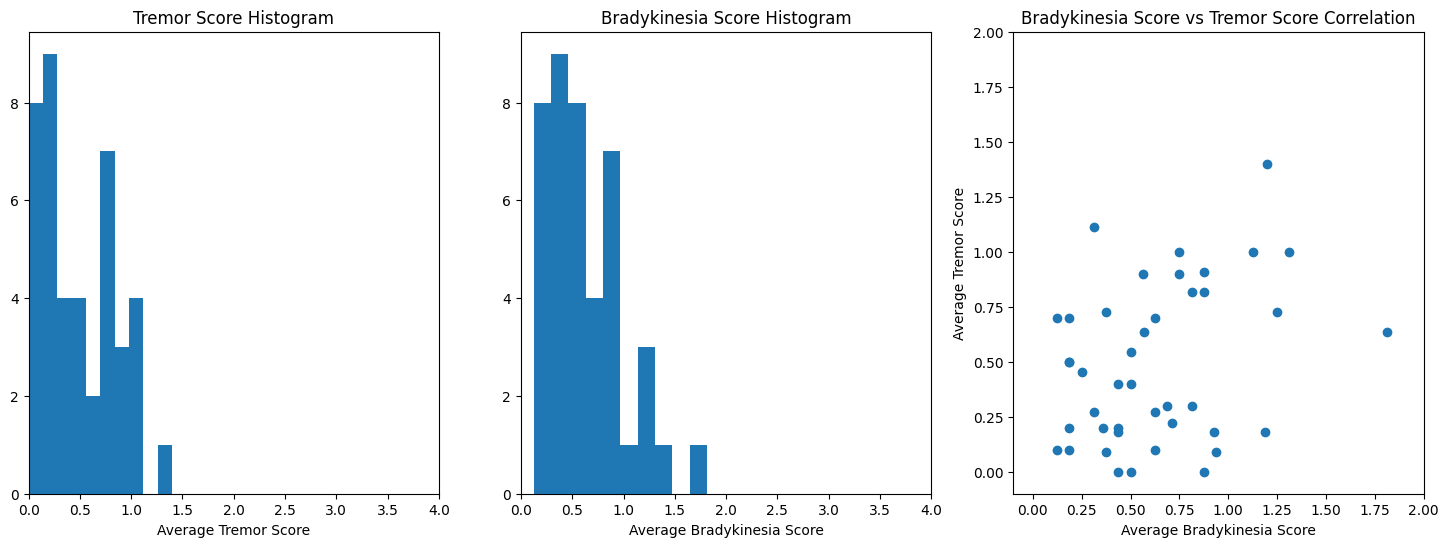

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].hist(session_metadata['tremor_score']),
ax[0].set_title('Tremor Score Histogram')
ax[0].set_xlabel('Average Tremor Score')
ax[0].set_xlim(0, 4)
ax[1].hist(session_metadata['bradykinesia_score'])
ax[1].set_title('Bradykinesia Score Histogram')
ax[1].set_xlabel('Average Bradykinesia Score')
ax[1].set_xlim(0, 4)
ax[2].plot(session_metadata['bradykinesia_score'], session_metadata['tremor_score'], 'o')
ax[2].set_title('Bradykinesia Score vs Tremor Score Correlation')
ax[2].set_xlabel('Average Bradykinesia Score')
ax[2].set_ylabel('Average Tremor Score')
ax[2].set_xlim(-0.1, 2)
ax[2].set_ylim(-0.1, 2)

### Save data and data results (metadata)

In [40]:
session_metadata


,subject_id,gender,age,years_since_diagnosis,pd_meds,is_pd,treatment,off_med_first,is_tremor_dominant,MoCA,sMMSE,BDI,BAI,UPDRS,off_meds_hrs,210_Tremor,212_Balance,213_Freezing,301_Speech,302_Facial_Expression,303a_Rigidity_Neck,303b_Rigidity_RUE,303c_Rigidity_LUE,303d_Rigidity_RLE,303e_Rigidity_LLE,304a_Finger_Tapping_RUE,304b_Finger_Tapping_LUE,305a_Hand_Movements_RUE,305b_Hand_Movements_LUE,306a_Pronation_Supination_Movements_RUE,306b_Pronation_Supination_Movements_LUE,307a_Toe_Tapping_RLE,307b_Toe_Tapping_LLE,308a_Leg_Agility_RLE,308b_Leg_Agility_LLE,309_Arising_from_Chair,310_Gait,311_Freezing_of_Gait,312_Postural_Stability,313_Posture,314_Global_Spontaneity_of_Movement,315a_Postural_Tremor_RUE,315b_Postural_Tremor_LUE,316a_Kinetic_Tremor_RUE,316b_Kinetic_Tremor_LUE,317a_Rest_Tremor_Amplitude_RUE,317b_Rest_Tremor_Amplitude_LUE,317c_Rest_Tremor_Amplitude_RLE,317d_Rest_Tremor_Amplitude_LLE,317e_Rest_Tremor_Amplitude_Lip_Jaw,318_Constancy_of_Rest_Tremor,Were_Diskinesias_Present,Did_these_Movements_Interfere_with_Ratings,Hoehn_and_Yahr_Stage,notes,Unnamed: 55,experiment_site,prior_condition,file_name,positive_bias,positive_psych_alpha,positive_psych_beta,positive_psych_lapse,positive_psych_guess,equal_psych_bias,equal_psych_alpha,equal_psych_beta,equal_psych_lapse,equal_psych_guess,positive_psych_bias,equal_bias,session_id,tremor_score,bradykinesia_score,pigd_score,trem_by_brady,trem_by_pigd,trem_vs_brady_type,pigd_vs_tremor_type,trem_vs_non-trem,pigd_vs_non-pigd,UPDRS_improvement,tremor_improvement,bradykinesia_improvement
0,P1,M,64.0,7.0,carbidopa-levodopa (Sinemet) 25-100 mg tablet;...,1,OFF,1.0,NaN,NaN,NaN,NaN,NaN,18.0,24,1.0,1.0,2.0,0.0,1.0,1.0,0.0,2.0,NaN,NaN,1.0,2.0,1.0,2.0,1.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,NaN,Stanford,rr,P1_OFFmeds_rr.mat,0.394737,9.548708,0.052991,0.006751,0.011776,0.429653,7.795582,0.063467,0.021178,0.094816,0.380941,0.414286,P1_OFF,0.181818,0.928571,1.000000,0.195804,0.181818,bradykinetic,pigd,non-tremor,pigd,5.555556,-65.000000,25.961538
1,P1,M,64.0,7.0,carbidopa-levodopa (Sinemet) 25-100 mg tablet;...,1,ON,1.0,NaN,26.0,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,0.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,NaN,Stanford,gr,P1_ONmeds_gr.mat,0.723684,-11.994054,0.067302,0.023186,0.100474,0.451841,5.865186,0.045781,0.000010,0.032772,0.706478,0.400000,P1_ON,0.300000,0.687500,0.666667,0.436364,0.450000,bradykinetic,pigd,non-tremor,pigd,5.555556,-65.000000,25.961538
2,P3,F,59.0,6.0,carbidopa-levodopa (Sinemet) 25-100 mg tablet,1,OFF,1.0,NaN,27.0,NaN,NaN,NaN,10.0,12.5,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,Stanford,rr,P3_OFFmeds_rr.mat,0.388889,6.631412,0.013245,0.200000,0.000010,0.406585,54.057324,0.019519,0.000010,0.200000,0.382450,0.482759,P3_OFF,0.454545,0.250000,0.200000,1.818182,2.272727,tremor,tremor,tremor,non-pigd,50.000000,78.000000,25.000000
3,P3,F,59.0,6.0,carbidopa-levodopa (Sinemet) 25-100 mg tablet,1,ON,1.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,NaN,Stanford,gr,P3_ONmeds_gr.mat,0.434211,55.269669,0.006553,0.200000,0.200000,0.379991,24.197426,0.012323,0.108020,0.000010,0.446258,0.379747,P3_ON,0.100000,0.187500,0.000000,0.533333,NaN,tremor,tremor,tremor,non-pigd,50.000000,78.000000,25.000000
4,P4,M,79.0,3.0,carbidopa-levodopa (Sinemet CR) 25-100 mg tablet,1,OFF,1.0,NaN,29.0,NaN,NaN,NaN,18.0,25,1.0,0.0,0.0,1.0,3.0,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,2.0,NaN,NaN,2.0,NaN,NaN,Stanford,rl,P4_OFFmeds_rl.mat,0.571429,-8.139609,0.027590,0.004454,0.000010,0.471327,5.011135,0.050707,0.017031

In [41]:
session_metadata.to_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index=False)
